<a href="https://www.kaggle.com/code/lalit7881/coffee-quality-pricing-eda?scriptVersionId=352648051" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')  # Use Agg backend for matplotlib

# Ensure plots are rendered inline
%matplotlib inline

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/razanihababdellatif/coffee-quality-and-pricing-benchmark/coffee_record_metadata.csv
/kaggle/input/datasets/razanihababdellatif/coffee-quality-and-pricing-benchmark/coffee_value_benchmark.csv
/kaggle/input/datasets/razanihababdellatif/coffee-quality-and-pricing-benchmark/feature_dictionary.csv
/kaggle/input/datasets/razanihababdellatif/coffee-quality-and-pricing-benchmark/coffee_benchmark_splits.csv


## Loading dataset

In [2]:
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

In [3]:
# Coffee benchmark splits
coffee_benchmark_splits_path = resolve_data_file(file_name='coffee_benchmark_splits.csv', suffixes=['.csv'])
df_benchmark_splits = pd.read_csv(coffee_benchmark_splits_path, encoding='ascii', delimiter=',')

# Coffee record metadata
coffee_record_metadata_path = resolve_data_file(file_name='coffee_record_metadata.csv', suffixes=['.csv'])
df_record_metadata = pd.read_csv(coffee_record_metadata_path, encoding='ascii', delimiter=',')

# Coffee value benchmark
coffee_value_benchmark_path = resolve_data_file(file_name='coffee_value_benchmark.csv', suffixes=['.csv'])
df_value = pd.read_csv(coffee_value_benchmark_path, encoding='ascii', delimiter=',')

# Feature dictionary
feature_dictionary_path = resolve_data_file(file_name='feature_dictionary.csv', suffixes=['.csv'])
df_feature_dict = pd.read_csv(feature_dictionary_path, encoding='ascii', delimiter=',')

# Basic checks on loaded data (head and info, outputs not shown here)
print('Datasets loaded successfully')

Datasets loaded successfully


In [4]:
print('Coffee Benchmark Splits shape:', df_benchmark_splits.shape)
print('Coffee Record Metadata shape:', df_record_metadata.shape)
print('Coffee Value Benchmark shape:', df_value.shape)
print('Feature Dictionary shape:', df_feature_dict.shape)

Coffee Benchmark Splits shape: (35000, 2)
Coffee Record Metadata shape: (35700, 3)
Coffee Value Benchmark shape: (35700, 36)
Feature Dictionary shape: (36, 8)


In [5]:
print('Missing values per column:')
print(df_value.isnull().sum())

Missing values per column:
record_id                     0
lot_id                        0
harvest_season                0
harvest_calendar_year         0
harvest_month                 0
country_of_origin             0
farm_type                     0
farm_size_hectares            0
tree_age_years                0
altitude_mean_meters          0
species                       0
avg_temp_c                    0
avg_annual_rainfall_mm     1819
humidity_pct               2282
processing_method             0
drying_method                 0
drying_duration_days          0
storage_months                0
storage_conditions            0
bean_size_screen              0
moisture_pct               1612
bean_density_g_ml          1632
defect_rate_pct               0
traceability_level            0
certification             21723
intended_buyer_segment        0
lot_size_kg                   0
roast_level                   0
acidity_score                 0
sweetness_score               0
body_score   

In [6]:
numeric_df = df_value.select_dtypes(include=[np.number])

In [7]:
imputer = SimpleImputer(strategy='mean')
numeric_imputed = imputer.fit_transform(numeric_df)

In [8]:
df_value_clean = pd.DataFrame(numeric_imputed, columns=numeric_df.columns)

print('Data cleaning completed. Missing values in numeric data have been imputed.')

Data cleaning completed. Missing values in numeric data have been imputed.


## EDA

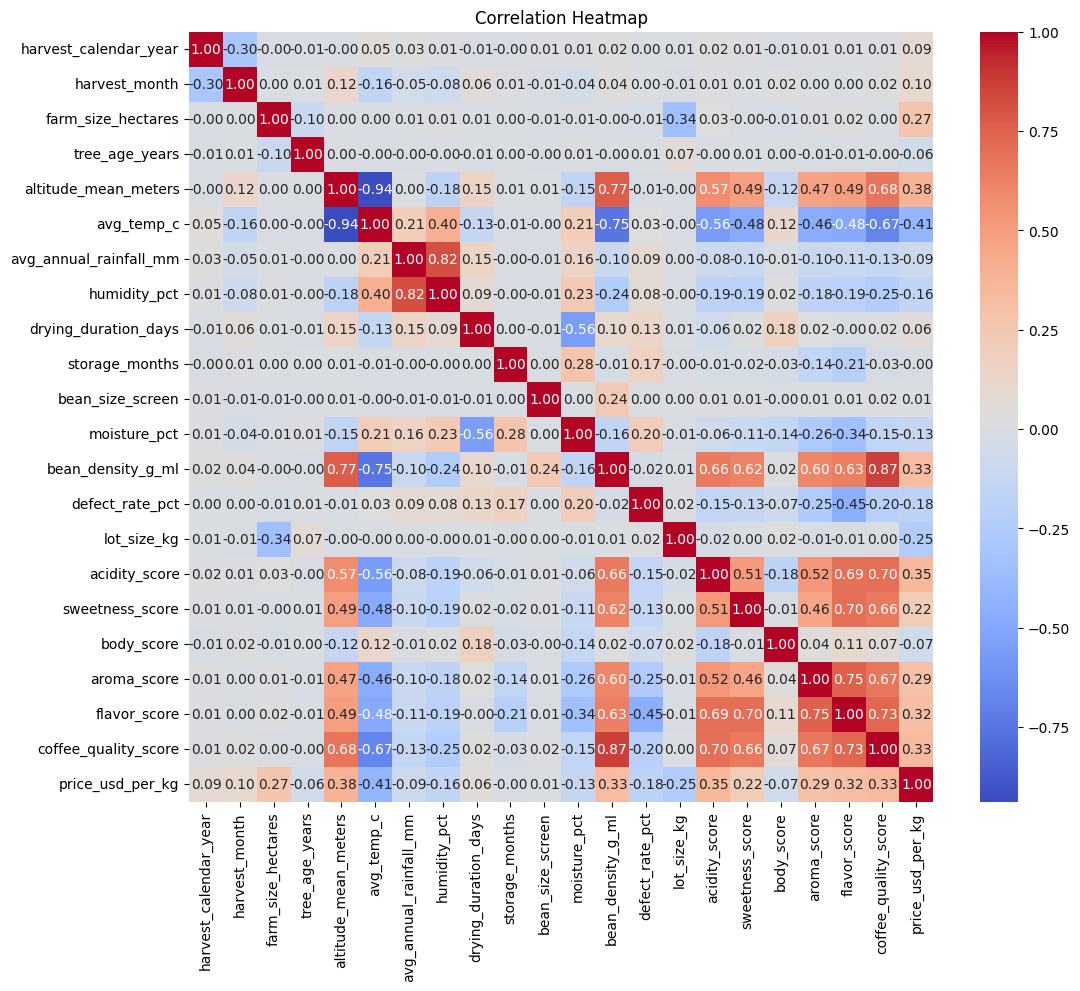

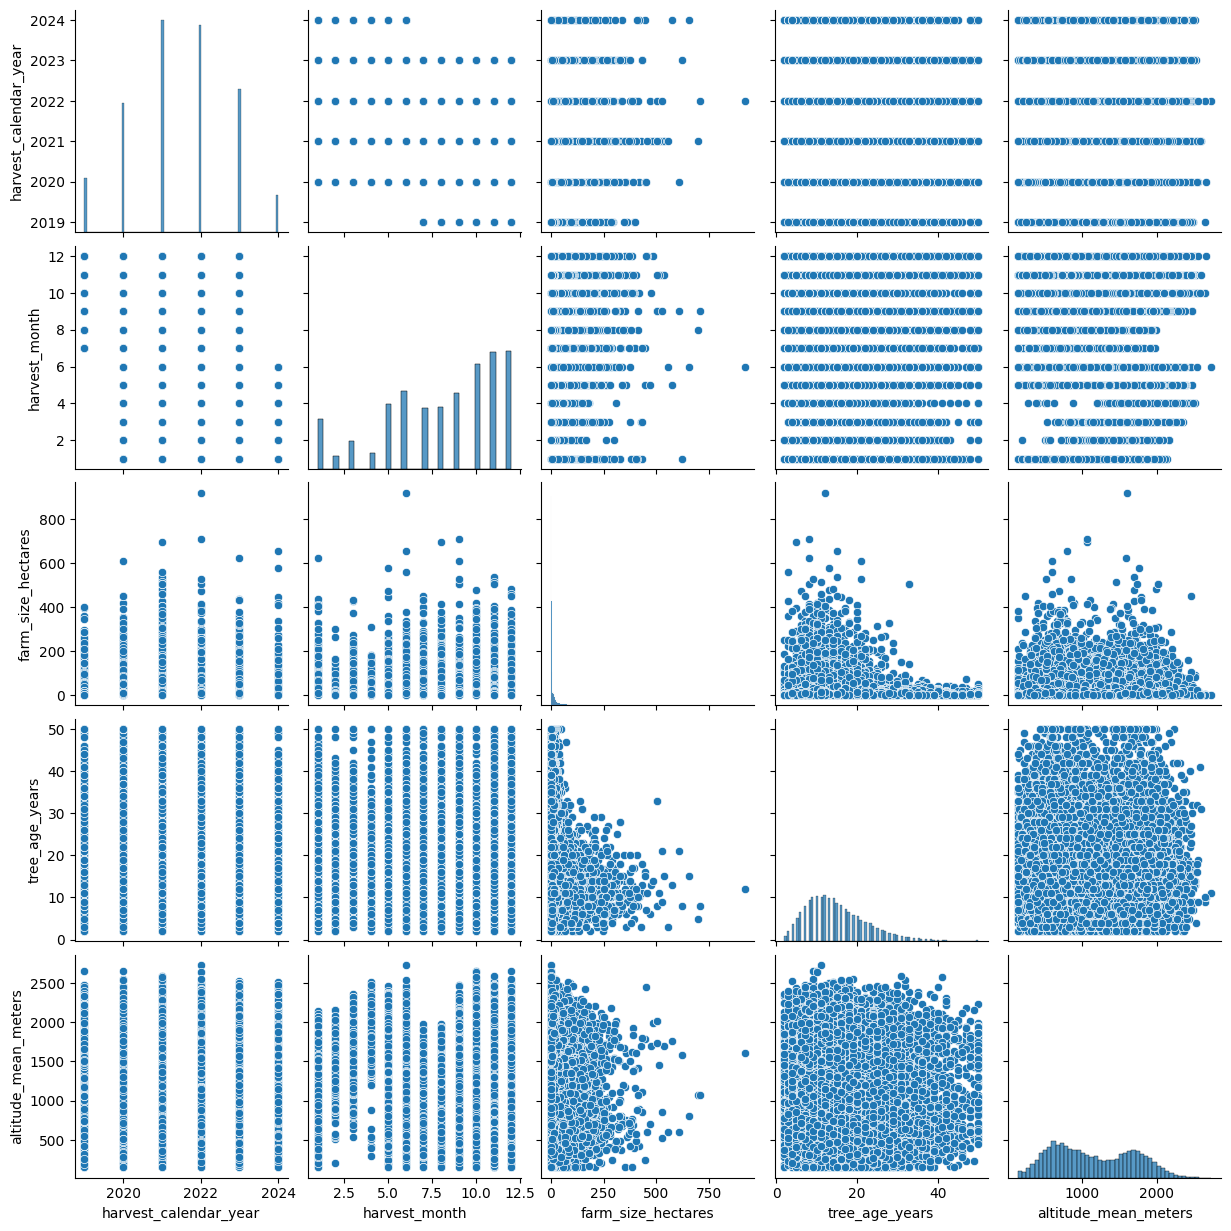

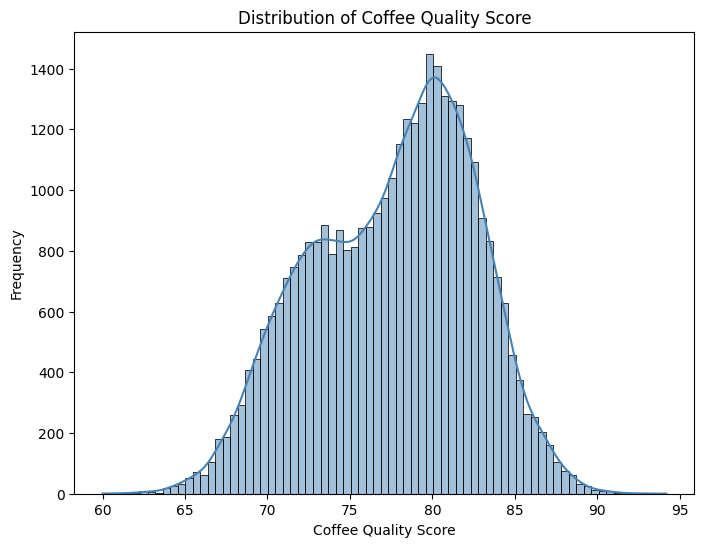

In [9]:
# Select numeric columns from the cleaned value benchmark dataset
numeric_df_clean = df_value_clean.select_dtypes(include=[np.number])

# Plot a correlation heatmap if there are four or more numeric columns
if numeric_df_clean.shape[1] >= 4:
    plt.figure(figsize=(12, 10))
    corr_matrix = numeric_df_clean.corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()

# Create a pair plot for a subset of numeric columns to visualize pairwise relationships
sample_columns = numeric_df_clean.columns[:5]  # limit to first five columns for clarity
sns.pairplot(df_value_clean[sample_columns])
plt.show()

# Plot histogram of the coffee quality score
plt.figure(figsize=(8, 6))
sns.histplot(df_value_clean['coffee_quality_score'], kde=True, color='steelblue')
plt.title('Distribution of Coffee Quality Score')
plt.xlabel('Coffee Quality Score')
plt.ylabel('Frequency')
plt.show()

## Feature engineering


Feature columns:
['harvest_calendar_year', 'harvest_month', 'farm_size_hectares', 'tree_age_years', 'altitude_mean_meters', 'avg_temp_c', 'avg_annual_rainfall_mm', 'humidity_pct', 'drying_duration_days', 'storage_months', 'bean_size_screen', 'moisture_pct', 'bean_density_g_ml', 'defect_rate_pct', 'lot_size_kg', 'acidity_score', 'sweetness_score', 'body_score', 'aroma_score', 'flavor_score', 'price_usd_per_kg']

Feature shape: (35700, 21)
Target shape: (35700,)

Training samples: 28560
Testing samples: 7140

Training: Linear Regression
R² Score : 0.8597
MSE      : 3.3922
RMSE     : 1.8418
MAE      : 1.4256

Training: Ridge Regression
R² Score : 0.8597
MSE      : 3.3922
RMSE     : 1.8418
MAE      : 1.4256

Training: Lasso Regression
R² Score : 0.8592
MSE      : 3.4054
RMSE     : 1.8454
MAE      : 1.4296

Training: Decision Tree
R² Score : 0.8322
MSE      : 4.0571
RMSE     : 2.0142
MAE      : 1.5829

Training: Random Forest
R² Score : 0.8653
MSE      : 3.2582
RMSE     : 1.8051
MAE      : 

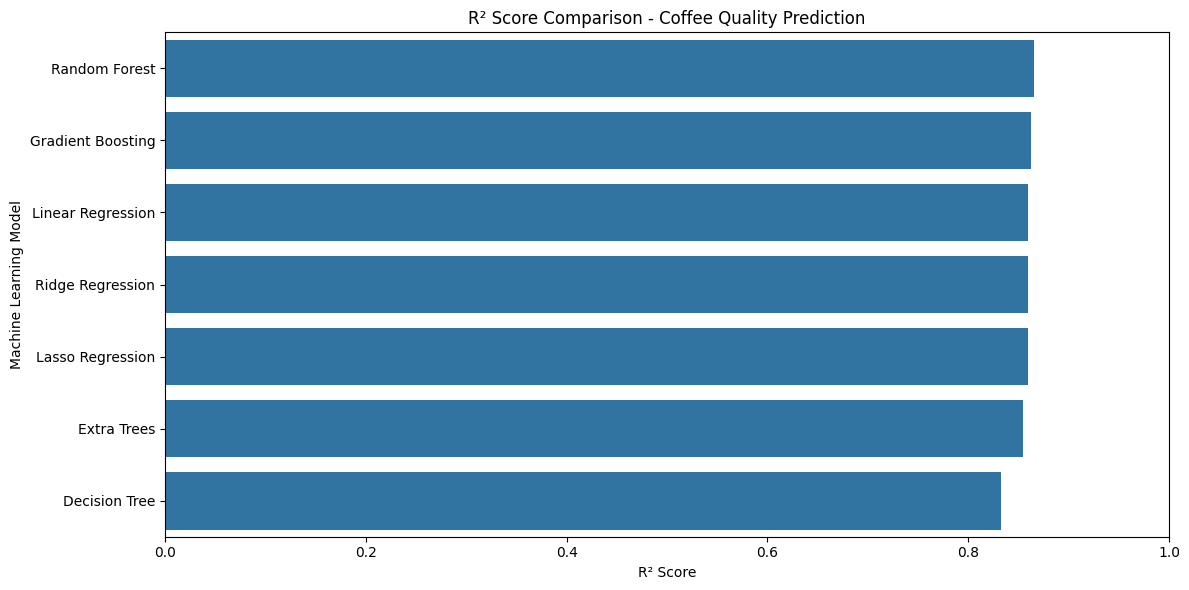

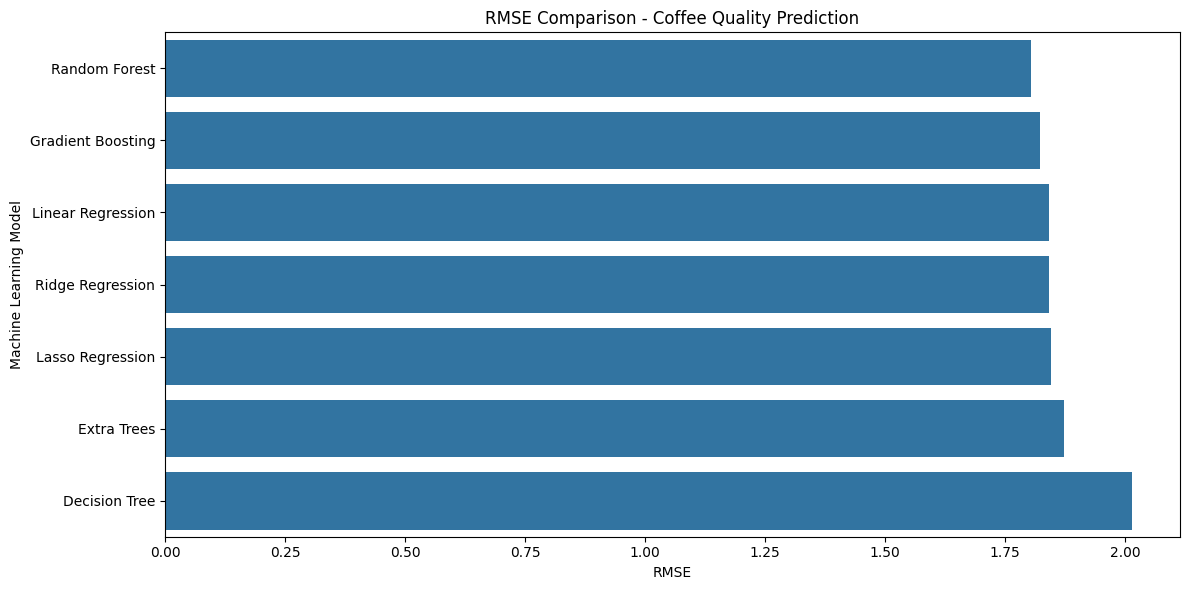

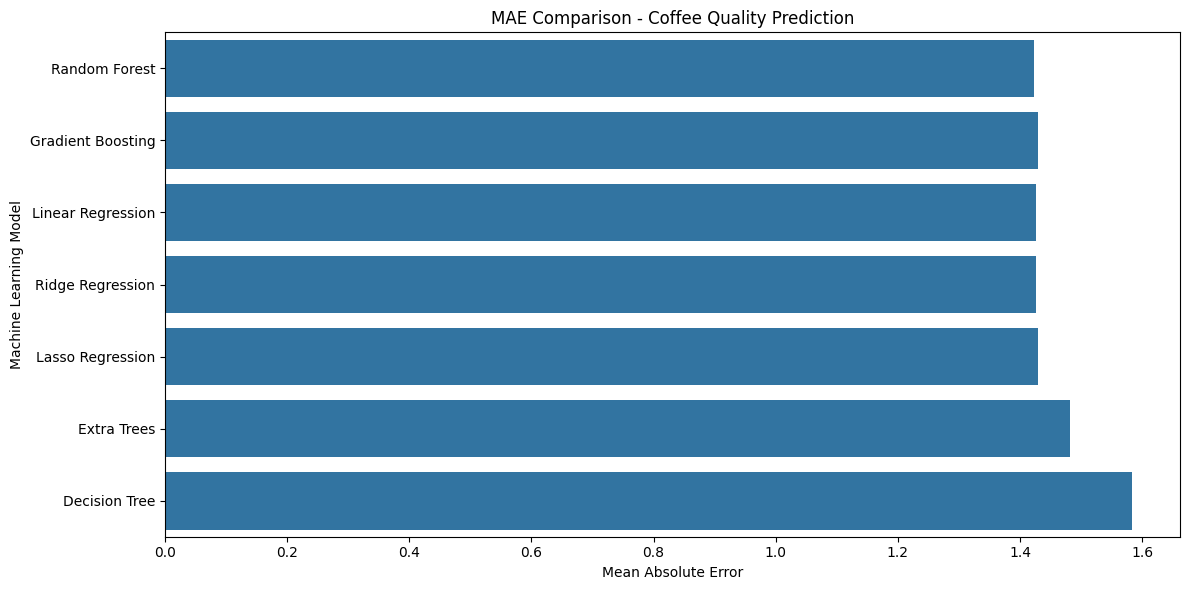


Best model based on test R²:
Random Forest


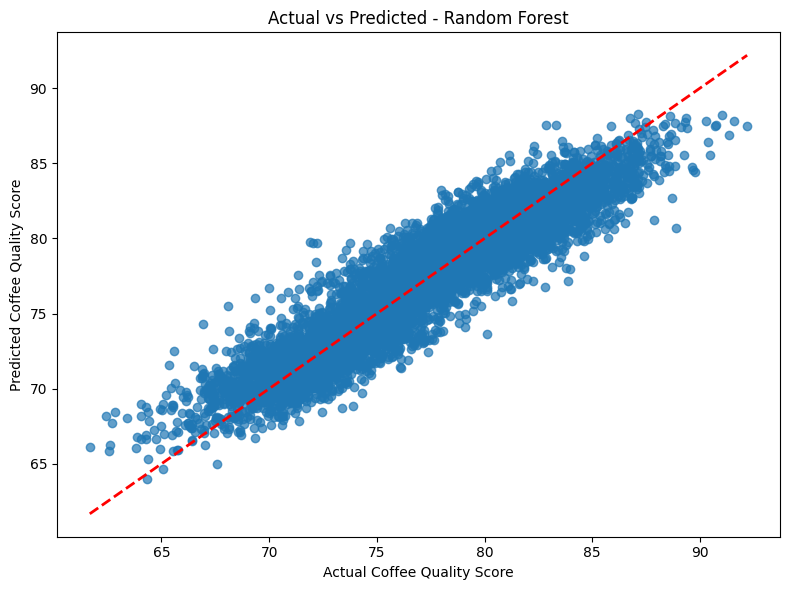

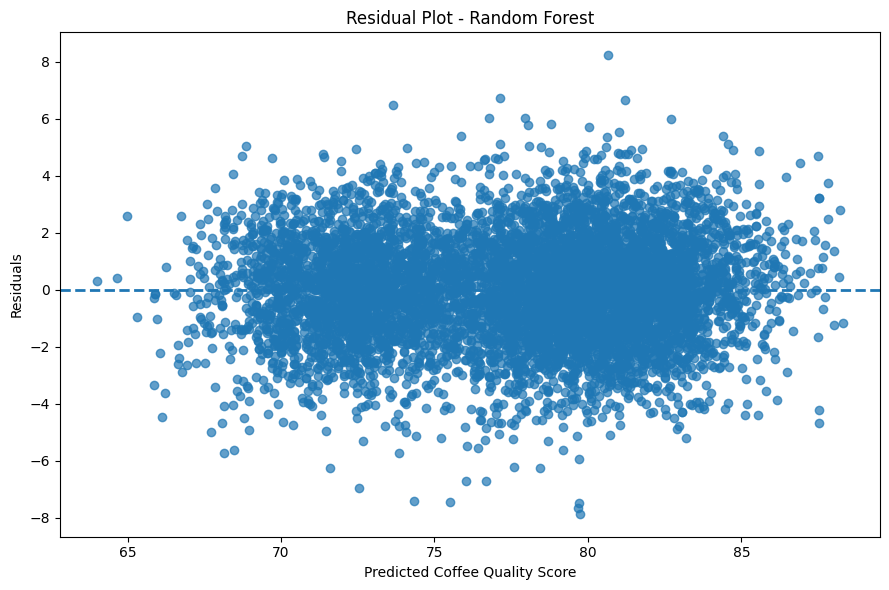

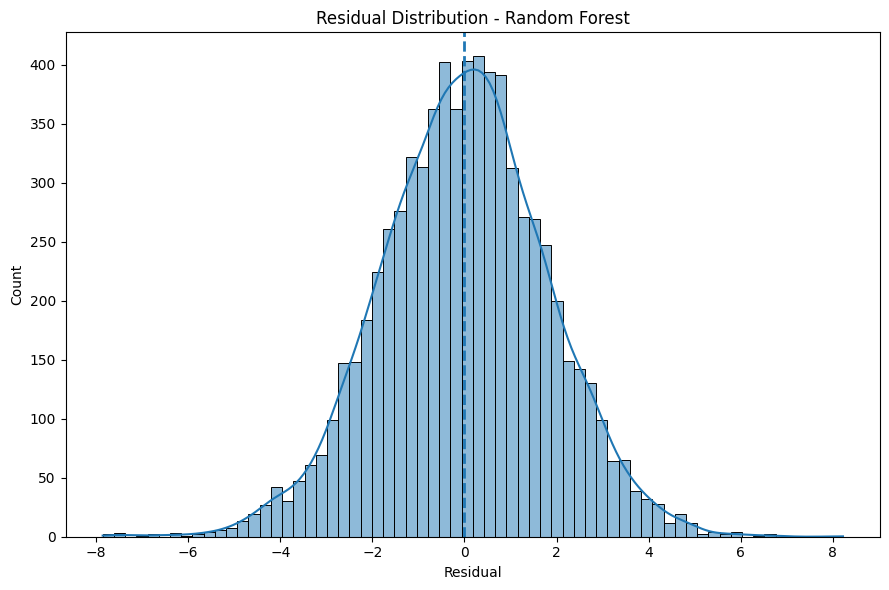



5-FOLD CROSS VALIDATION
Linear Regression: Mean R² = 0.8587, Std = 0.0039
Ridge Regression: Mean R² = 0.8587, Std = 0.0039
Lasso Regression: Mean R² = 0.8585, Std = 0.0038
Decision Tree: Mean R² = 0.8353, Std = 0.0041
Random Forest: Mean R² = 0.8672, Std = 0.0040
Gradient Boosting: Mean R² = 0.8622, Std = 0.0033
Extra Trees: Mean R² = 0.8564, Std = 0.0033

Cross-validation comparison:
               Model  CV Mean R2    CV Std
4      Random Forest    0.867231  0.004032
5  Gradient Boosting    0.862244  0.003260
1   Ridge Regression    0.858687  0.003912
0  Linear Regression    0.858687  0.003913
2   Lasso Regression    0.858460  0.003812
6        Extra Trees    0.856373  0.003329
3      Decision Tree    0.835317  0.004105


FEATURE IMPORTANCE
                   Feature  Importance
12       bean_density_g_ml    0.841235
19            flavor_score    0.062748
10        bean_size_screen    0.025997
5               avg_temp_c    0.012823
13         defect_rate_pct    0.012121
4     altit

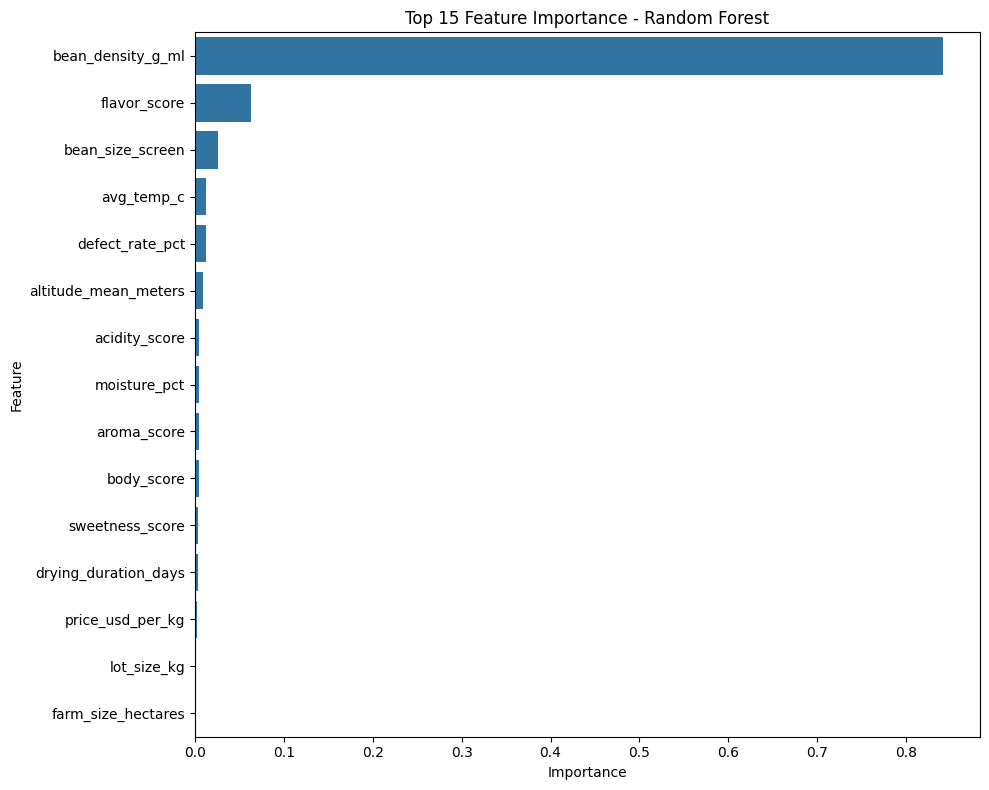



SAMPLE PREDICTIONS
    Actual  Predicted  Residual
0    80.27  79.325792  0.944208
1    78.39  76.571779  1.818221
2    80.13  80.203011 -0.073011
3    71.95  70.618138  1.331862
4    78.13  75.996498  2.133502
5    67.46  68.855625 -1.395625
6    75.32  73.269600  2.050400
7    82.48  83.162718 -0.682718
8    78.07  78.259169 -0.189169
9    83.52  80.510042  3.009958
10   82.19  82.191181 -0.001181
11   75.57  75.432861  0.137139
12   83.15  84.260767 -1.110767
13   71.58  71.150000  0.430000
14   79.47  77.505393  1.964607
15   78.51  80.087607 -1.577607
16   79.14  78.920797  0.219203
17   75.11  76.730067 -1.620067
18   70.60  72.652170 -2.052170
19   79.69  79.009812  0.680188


FINAL BEST MODEL EVALUATION
Best Model : Random Forest
R² Score   : 0.8653
MSE        : 3.2582
RMSE       : 1.8051
MAE        : 1.4224


In [10]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


# ============================================================
# 2. Prepare Data
# ============================================================

numeric_df_model = df_value_clean.copy()

# Check target
if 'coffee_quality_score' not in numeric_df_model.columns:
    raise ValueError(
        "Target column 'coffee_quality_score' not found."
    )

# Remove rows where target is missing
numeric_df_model = numeric_df_model.dropna(
    subset=['coffee_quality_score']
)

# Separate features and target
X = numeric_df_model.drop(
    'coffee_quality_score',
    axis=1
)

y = numeric_df_model['coffee_quality_score']


# ============================================================
# 3. Make Sure Features are Numeric
# ============================================================

# Keep only numeric columns
X = X.select_dtypes(include=np.number)

print("Feature columns:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)


# ============================================================
# 4. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ============================================================
# 5. Define Models
# ============================================================

models = {

    "Linear Regression":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),

    "Ridge Regression":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0))
        ]),

    "Lasso Regression":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(alpha=0.01))
        ]),

    "Decision Tree":
        DecisionTreeRegressor(
            max_depth=8,
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
}


# ============================================================
# 6. Train Models and Evaluate
# ============================================================

results = []

trained_models = {}

predictions = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print("Training:", name)
    print("=" * 60)

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Store trained model
    trained_models[name] = model

    # Store predictions
    predictions[name] = y_pred

    # Metrics
    r2 = r2_score(y_test, y_pred)

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    })

    print(f"R² Score : {r2:.4f}")
    print(f"MSE      : {mse:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}")


# ============================================================
# 7. Model Comparison
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print("\n")
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

print(results_df)


# ============================================================
# 8. R² Score Comparison
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="R2 Score",
    y="Model"
)

plt.title(
    "R² Score Comparison - Coffee Quality Prediction"
)

plt.xlabel("R² Score")
plt.ylabel("Machine Learning Model")

plt.xlim(
    min(0, results_df["R2 Score"].min() - 0.05),
    1
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. RMSE Comparison
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)

plt.title(
    "RMSE Comparison - Coffee Quality Prediction"
)

plt.xlabel("RMSE")
plt.ylabel("Machine Learning Model")

plt.tight_layout()
plt.show()


# ============================================================
# 10. MAE Comparison
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="MAE",
    y="Model"
)

plt.title(
    "MAE Comparison - Coffee Quality Prediction"
)

plt.xlabel("Mean Absolute Error")
plt.ylabel("Machine Learning Model")

plt.tight_layout()
plt.show()


# ============================================================
# 11. Select Model with Highest R²
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

best_predictions = predictions[
    best_model_name
]

print("\nBest model based on test R²:")
print(best_model_name)


# ============================================================
# 12. Actual vs Predicted
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    'r--',
    linewidth=2
)

plt.xlabel(
    "Actual Coffee Quality Score"
)

plt.ylabel(
    "Predicted Coffee Quality Score"
)

plt.title(
    f"Actual vs Predicted - {best_model_name}"
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. Residual Calculation
# ============================================================

residuals = y_test - best_predictions


# ============================================================
# 14. Residual Plot
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=2
)

plt.xlabel(
    "Predicted Coffee Quality Score"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    f"Residual Plot - {best_model_name}"
)

plt.tight_layout()
plt.show()


# ============================================================
# 15. Residual Distribution
# ============================================================

plt.figure(figsize=(9, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.axvline(
    x=0,
    linestyle='--',
    linewidth=2
)

plt.title(
    f"Residual Distribution - {best_model_name}"
)

plt.xlabel("Residual")

plt.tight_layout()
plt.show()


# ============================================================
# 16. Cross Validation
# ============================================================

print("\n")
print("=" * 80)
print("5-FOLD CROSS VALIDATION")
print("=" * 80)

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='r2'
    )

    cv_results.append({
        "Model": name,
        "CV Mean R2": scores.mean(),
        "CV Std": scores.std()
    })

    print(
        f"{name}: "
        f"Mean R² = {scores.mean():.4f}, "
        f"Std = {scores.std():.4f}"
    )


cv_results_df = pd.DataFrame(
    cv_results
).sort_values(
    by="CV Mean R2",
    ascending=False
)

print("\nCross-validation comparison:")
print(cv_results_df)


# ============================================================
# 17. Feature Importance
# ============================================================

# Tree-based models have feature_importances_
tree_models = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "Extra Trees"
]

if best_model_name in tree_models:

    # Get actual model from pipeline if necessary
    if hasattr(best_model, "named_steps"):
        model_for_importance = best_model.named_steps["model"]
    else:
        model_for_importance = best_model

    importances = model_for_importance.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    })

    feature_importance_df = feature_importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    print("\n")
    print("=" * 80)
    print("FEATURE IMPORTANCE")
    print("=" * 80)

    print(feature_importance_df)


    # Plot feature importance
    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=feature_importance_df.head(15),
        x="Importance",
        y="Feature"
    )

    plt.title(
        f"Top 15 Feature Importance - {best_model_name}"
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


# ============================================================
# 18. Prediction Table
# ============================================================

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions,
    "Residual": y_test.values - best_predictions
})

print("\n")
print("=" * 80)
print("SAMPLE PREDICTIONS")
print("=" * 80)

print(
    prediction_df.head(20)
)


# ============================================================
# 19. Final Evaluation
# ============================================================

final_r2 = r2_score(
    y_test,
    best_predictions
)

final_mse = mean_squared_error(
    y_test,
    best_predictions
)

final_rmse = np.sqrt(
    final_mse
)

final_mae = mean_absolute_error(
    y_test,
    best_predictions
)

print("\n")
print("=" * 80)
print("FINAL BEST MODEL EVALUATION")
print("=" * 80)

print("Best Model :", best_model_name)
print(f"R² Score   : {final_r2:.4f}")
print(f"MSE        : {final_mse:.4f}")
print(f"RMSE       : {final_rmse:.4f}")
print(f"MAE        : {final_mae:.4f}")

## Thank you..pls upvote!!!